<a href="https://colab.research.google.com/github/Prerna23005/Data_Science_Project/blob/main/OBJECTDETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import os

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL.Image , PIL.ImageFont, PIL.ImageDraw
import tensorflow as tf
import tensorflow_datasets as tfds


VISUALIZATION UTILITIES

In [70]:
im_width = 75
im_height = 75
use_normalizes_coordinates = True

In [71]:
def draw_bounding_boxes_on_array(image,boxes,color=[],thickness=1, display_str_list=()):
  image_pil = PIL.Image.fromarray(image)
  rgbimg = PIL.Image.new("RGBA", image_pil.size)
  rgbimg.paste(image_pil)
  draw_bounding_boxes_in_images(rgbimg, boxes, color, thickness, display_str_list)
  return np.array(rgbimg)

def draw_bounding_boxes_in_images(iimage, boxes, color=[], thickness=1, display_str_list=()):
  boxes_shape = boxes.shape
  if not boxes_shape:
    return
  if len(boxes_shape) != 2 or boxes_shape[1] != 4:
     raise ValueError('Input must be of size [N,4]')
  for i in range(boxes_shape[0]):
    current_color = color[i] if color else 'red'
    current_display_str = display_str_list[i] if display_str_list else None
    draw_bounding_box_on_image(iimage, boxes[i,1], boxes[i,0], boxes[i,3], boxes[i,2], current_color, thickness, current_display_str)

def draw_bounding_box_on_image(image, ymin, xmin, ymax, xmax, color='red', thickness=1, display_str_list = None, use_normalized_coordinates = True):
  draw = PIL.ImageDraw.Draw(image)
  im_width, im_height = image.size
  if use_normalized_coordinates:
    (left,right,top,bottom) = (xmin * im_width, xmax * im_width, ymin * im_height, ymax * im_height)
  else:
    (left,right,top,bottom) = (xmin, xmax, ymin, ymax)

  draw.line([(left,top),(left,bottom), (right,bottom),(right,top),(left,top)],width=thickness, fill=color)

In [72]:
def dataset_to_numpy_util(training_dataset, validation_dataset, N):
    batch_train_ds = training_dataset.unbatch().batch(N)

    if tf.executing_eagerly():
        for validation_digits, (validation_labels, validation_bboxes) in validation_dataset:
            validation_digits = validation_digits.numpy()
            validation_labels = validation_labels.numpy()
            validation_bboxes = validation_bboxes.numpy()
            break
        for training_digits, (training_labels, training_bboxes) in training_dataset:
            training_digits = training_digits.numpy()
            training_labels = training_labels.numpy()
            training_bboxes = training_bboxes.numpy()
            break

    validation_labels = np.argmax(validation_labels, axis = 1)
    training_labels = np.argmax(training_labels, axis = 1)
    return (training_digits, training_labels, training_bboxes, validation_digits, validation_labels, validation_bboxes)

In [73]:
MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), "mpl-data/fonts/ttf")
def create_digits_from_local_fonts(n):
  font_labels = []
  img = PIL.Image.new('LA',(75*n, 75), color = (0,255))
  font1 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'DejaVuSansMono-Oblique.ttf'),25)
  font2 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'STIXGeneral.ttf'),25)
  d = PIL.ImageDraw.Draw(img)
  for i in range(n):
    font_labels.append(i%10)
    d.text((7+i*75,0 if i<10 else -4), str(i%10), fill=(255,255), font=font1 if i<10 else font2)
    font_digits = np.array(img.getdata(), np.float32)[:,0] / 255.0
    font_digits = np.reshape(np.stack(np.split(np.reshape(font_digits, [75,75*n]), n, axis=1), axis=0), [n,75*75])
    return font_digits, font_labels

In [74]:
def display_digits_with_boxes(digits, predictions, labels, pred_bboxes, bboxes, iou, title, iou_threshold=0.5):

    n = 3

    indexes = np.random.choice(len(predictions), size = n)
    n_predictions = predictions[indexes]
    n_labels = labels[indexes]

    n_iou = []
    if len(iou) > 0:
        n_iou = iou[indexes]

    n_pred_bboxes = []
    if len(pred_bboxes) > 0:
        n_pred_bboxes = pred_bboxes[indexes]

    n_bboxes = []
    if len(bboxes) > 0:
        n_bboxes = bboxes[indexes]

    n_digits = digits[indexes] * 255.0
    n_digits = n_digits.reshape(n, 75, 75)
    fig = plt.figure(figsize=(20,4))
    plt.title(title)
    plt.yticks([])
    plt.xticks([])

    for i in range(n):
        ax = fig.add_subplot(1,n,i+1)

        current_bboxes_to_plot = []
        current_display_str_list = []
        current_colors = []

        if len(n_bboxes) > 0:
            current_bboxes_to_plot.append(n_bboxes[i])
            current_display_str_list.append("True")
            current_colors.append('red')

        if len(n_pred_bboxes) > 0:
            current_bboxes_to_plot.append(n_pred_bboxes[i])
            current_display_str_list.append("Pred")
            current_colors.append('green')

        if len(current_bboxes_to_plot) > 0:
            img_to_draw = draw_bounding_boxes_on_array(
                image=n_digits[i],
                boxes=np.asarray(current_bboxes_to_plot),
                color=current_colors,
                display_str_list=current_display_str_list
            )
        else:
            img_to_draw = n_digits[i]

        plt.xlabel(n_predictions[i])
        plt.xticks([])
        plt.yticks([])

        if n_predictions[i] != n_labels[i]:
            ax.xaxis.label.set_color('red')

        plt.imshow(img_to_draw)

        if len(n_iou) > 0 and i < len(n_iou): # Ensure i is within bounds for n_iou
            color = "black"
            if(n_iou[i][0] < iou_threshold):
                color = "red"
            ax.text(0.2, -0.3, "iou: %s" %(n_iou[i][0]), color = color, transform=ax.transAxes)

    plt.show()

In [75]:

def plotmetrics(metric_name, title):
  plt.title(title)
  plt.plot(history.history[metric_name], color='blue',  label = metric_name)
  plt.plot(history.history['val_' + metric_name], color='green',label = 'val_' + metric_name)


# LOADING AND PREPROCESSING THE DATASET

In [76]:
strategy = tf.distribute.get_strategy()
strategy.num_replicas_in_sync

1

In [77]:
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

In [78]:
def read_image_tfds(image,label):
    xmin = tf.random.uniform((),0,48, dtype=tf.int32)
    ymin = tf.random.uniform((),0,48, dtype=tf.int32)
    image = tf.reshape(image,(28,28,1))
    image = tf.image.pad_to_bounding_box(image, ymin, xmin, 75, 75)
    image = tf.cast(image, tf.float32) / 255.0
    xmin = tf.cast(xmin, tf.float32)
    ymin = tf.cast(ymin, tf.float32)

    xmax = (xmin + 28) / 75
    ymax = (ymin + 28) / 75
    xmin = xmin / 75
    ymin = ymin / 75

    return image, (tf.one_hot(label, 10), [xmin, ymin, xmax, ymax])

In [79]:
def get_training_dataset():

    with strategy.scope():
         dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
         dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
         dataset = dataset.shuffle(5000, reshuffle_each_iteration=True)
         dataset = dataset.repeat()
         dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
         dataset = dataset.prefetch(1)
    return dataset

In [80]:
def get_validation_dataset():
    with strategy.scope():
        dataset = tfds.load("mnist", split="test", as_supervised=True, try_gcs=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls=16)
        dataset = dataset.batch(10000, drop_remainder = True)
        dataset = dataset.cache()

    return dataset

In [81]:

with strategy.scope():
   training_dataset = get_training_dataset()
   validation_dataset = get_validation_dataset()

In [82]:
(training_digits, training_labels, training_bboxes, validation_digits, validation_labels, validation_bboxes) = dataset_to_numpy_util(training_dataset, validation_dataset, 10)

VISUALIZE DATA

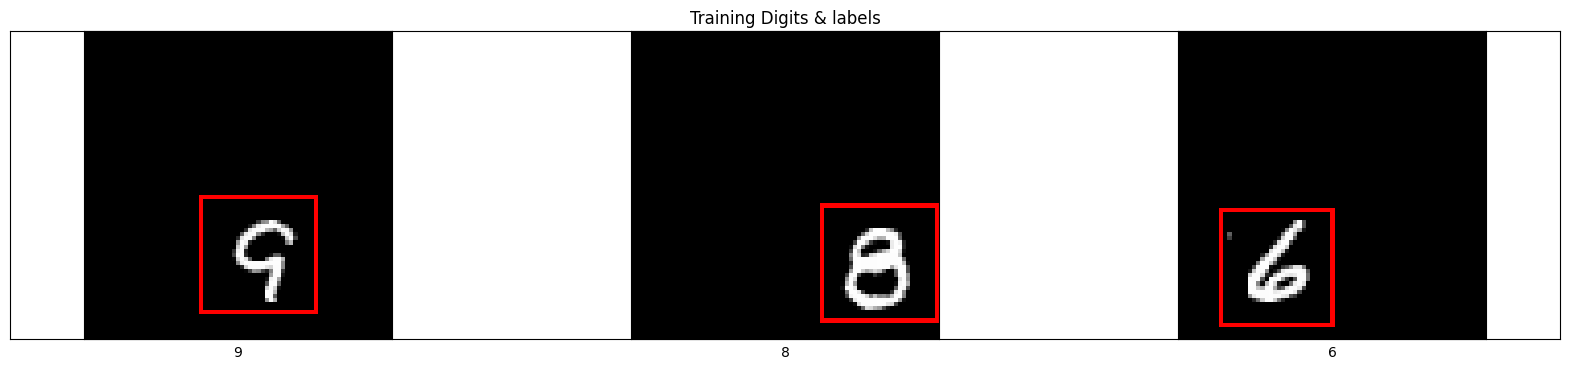

In [83]:
display_digits_with_boxes(training_digits, training_labels, training_labels, np.array([]), training_bboxes, np.array([]), "Training Digits & labels")

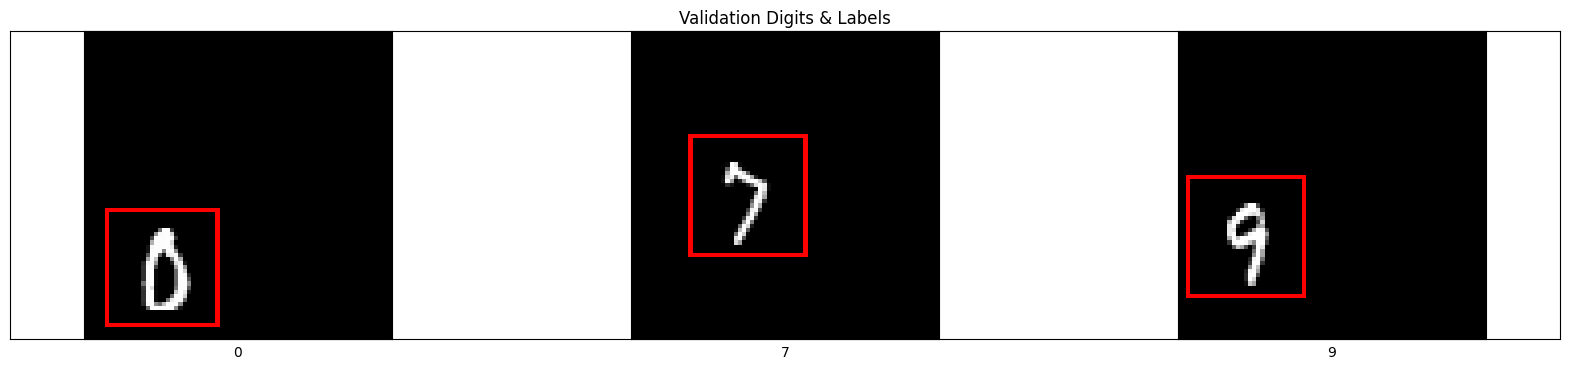

In [84]:
display_digits_with_boxes(validation_digits, validation_labels, validation_labels,np.array([]), validation_bboxes, np.array([]), "Validation Digits & Labels")

# define the network

In [85]:
def feature_extractor(inputs):
  x = tf.keras.layers.Conv2D(16, activation = 'relu', kernel_size=3, input_shape=(75,75,1))(inputs)
  x = tf.keras.layers.AveragePooling2D((2,2))(x)

  x = tf.keras.layers.Conv2D(32, activation = 'relu', kernel_size=3)(x)
  x = tf.keras.layers.AveragePooling2D((2,2))(x)

  x = tf.keras.layers.Conv2D(64, activation = 'relu', kernel_size=3)(x)
  x = tf.keras.layers.AveragePooling2D((2,2))(x)

  return x


In [86]:
def dense_layers(inputs):
  x = tf.keras.layers.Flatten()(inputs)
  x = tf.keras.layers.Dense(128, activation = 'relu')(x)
  return x

In [87]:
def classifier(inputs):
  classifictation_output = tf.keras.layers.Dense(10, activation = 'softmax', name = 'classification')(inputs)
  return classifictation_output

In [88]:
def bounding_box_regression(inputs):
  bounding_box_regression_outputs = tf.keras.layers.Dense(4, name = "bounding_box")(inputs)
  return bounding_box_regression_outputs

In [89]:
def final_model(inputs):
  feature_cnn = feature_extractor(inputs)
  dense_output = dense_layers(feature_cnn)

  classification_output = classifier(dense_output)
  bounding_box_output = bounding_box_regression(dense_output)

  model = tf.keras.Model(inputs = inputs, outputs = [classification_output, bounding_box_output])
  return model

In [90]:
def define_and_compile_model(inputs):
  model = final_model(inputs)

  model.compile(optimizer = 'adam', loss = {'classification': 'categorical_crossentropy', 'bounding_box': 'mse'}, metrics = {'classification': 'accuracy', 'bounding_box' : 'mse'})

  return model

In [91]:
with strategy.scope():
  inputs = tf.keras.layers.Input(shape = (75,75,1))
  model = define_and_compile_model(inputs)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_3 │ (None, 36, 36,    │          0 │ conv2d_3[0][0]    │
│ (AveragePooling2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 34, 34,    │      4,640 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_4 │ (None, 17, 17,    │          0 │ conv2d_4[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 15, 15,    │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_5 │ (None, 7, 7, 64)  │          0 │ conv2d_5[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    401,536 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box        │ (None, 4)         │        516 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

# Train and validate the model

In [ ]:
EPOCHS = 10
Steps_per_epoch= 500

history = model.fit(training_dataset, steps_per_epoch=Steps_per_epoch, validation_data=validation_dataset, validation_steps=1, epochs=EPOCHS)

loss,classification_loss, bounding_box_loss, classification_acc, bounding_box_mse = model.evaluate(validation_dataset, steps = 1)
print("-------------------------")
print("Validation Accuracy: ", classification_acc)
print("------------------------")

Epoch 1/10
146/500 ━━━━━━━━━━━━━━━━━━━━ 1:35 270ms/step - bounding_box_loss: 0.0536 - bounding_box_mse: 0.0536 - classification_accuracy: 0.1291 - classification_loss: 2.2856 - loss: 2.3393

In [ ]:
def intersetion_over_union(pred_box, true_box):
  xmin_pred, ymin_pred, xmax_pred, ymax_pred = np.split(pred_box, 4, axis = 1)
  xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis = 1)

  smoothing_factor = 1e-10

  xmin_overlap = np.maximum(xmin_pred, xmin_true)
  xmax_overlap = np.minimum(xmax_pred, xmax_true)
  ymin_overlap = np.maximum(ymin_pred, ymin_true)
  ymax_overlap = np.minimum(ymax_pred, ymax_true)

  pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
  true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

  overlap_area = np.maximum((xmax_overlap - xmin_overlap), 0) * np.maximum((ymax_overlap - ymin_overlap), 0)
  union_area = (pred_box_area + true_box_area) - overlap_area

  iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)

  return iou

In [ ]:
prediction = model.predict(validation_digits, batch_size = 64)

predicted_labels = np.argmax(prediction[0], axis = 1)

predicted_bboxes = prediction[1]



In [ ]:
iou = intersetion_over_union(predicted_bboxes, validation_bboxes)

iou_threshold = 0.6

display_digits_with_boxes(validation_digits, predicted_labels, validation_labels, predicted_bboxes, validation_bboxes, iou, "True and Pred values")